In [16]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import xarray as xr
import pandas as pd
import gsw, os
import copernicusmarine

In [11]:
df1 = xr.open_dataset('data/DeepArvorGrounding_ABYSS_June24.nc')
df1

<xarray.Dataset> Size: 281kB
Dimensions:    (N_GRD: 3906)
Dimensions without coordinates: N_GRD
Data variables:
    lat_gps    (N_GRD) float64 31kB ...
    lon_gps    (N_GRD) float64 31kB ...
    grnd       (N_GRD) float64 31kB ...
    jday_grnd  (N_GRD) datetime64[ns] 31kB ...
    jae_grnd   (N_GRD) datetime64[ns] 31kB ...
    jday_gps   (N_GRD) datetime64[ns] 31kB ...
    jds_grnd   (N_GRD) datetime64[ns] 31kB ...
    wmo        (N_GRD) int64 31kB ...
    cycle      (N_GRD) int64 31kB ...

## GLORY NZ CLIM

In [21]:
glomu = xr.open_dataset('Glorys_mean/mercatorglorys12v1_gl12_mean_uo-ave2000-2020-ave-all-deps.nc')
glomv = xr.open_dataset('Glorys_mean/mercatorglorys12v1_gl12_mean_vo-ave2000-2020-ave-all-deps.nc')
glomus = xr.open_dataset('Glorys_mean/mercatorglorys12v1_gl12_mean_uo-ave2000-2020-surf.nc')
glomvs = xr.open_dataset('Glorys_mean/mercatorglorys12v1_gl12_mean_vo-ave2000-2020-surf.nc')

In [138]:
gsurfu = glomus['uo'].interp(latitude=df1['lat_gps'],longitude=df1['lon_gps'])
gsurfv = glomvs['vo'].interp(latitude=df1['lat_gps'],longitude=df1['lon_gps'])
gcolu = glomu['uo'].interp(latitude=df1['lat_gps'],longitude=df1['lon_gps'])
gcolv = glomv['vo'].interp(latitude=df1['lat_gps'],longitude=df1['lon_gps'])

In [139]:
gsurfErr = np.empty(len(gsurfu))
gcolErr  = np.empty(len(gsurfu))
for i in range(len(gsurfErr)):
    du = df1.isel(N_GRD=i)
    ascent_duration = int((du.jday_gps - du.jday_grnd).values)/(1e9) #seconds
    drift_duration = int((du.jds_grnd - du.jae_grnd).values)/(1e9) #seconds
    gsurfErr[i] = np.sqrt((drift_duration*gsurfu[i])**2 + (drift_duration*gsurfv[i])**2)
    gcolErr[i] = np.sqrt((ascent_duration*gcolu[i])**2 + (ascent_duration*gcolv[i])**2)

In [141]:
gsurfErr[gsurfErr>2000]=np.nan

(array([1.186e+03, 2.085e+03, 4.750e+02, 9.500e+01, 3.400e+01, 1.200e+01,
        1.100e+01, 2.000e+00, 1.000e+00, 4.000e+00]),
 array([ 0.1872777 ,  8.79798317, 17.40868865, 26.01939412, 34.6300996 ,
        43.24080507, 51.85151055, 60.46221602, 69.0729215 , 77.68362697,
        86.29433245]),
 <BarContainer object of 10 artists>)

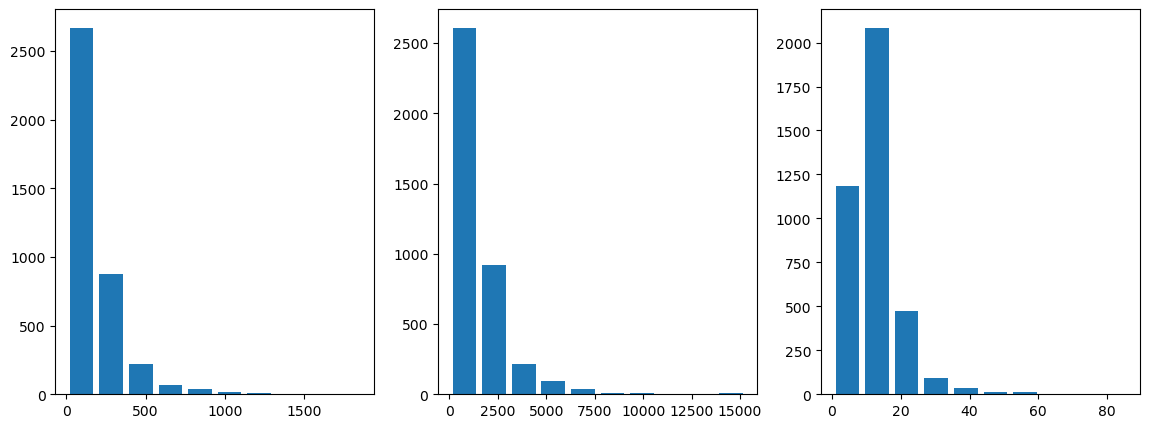

In [142]:
f,ax = plt.subplots(1,3,figsize=(14,5))
ax[0].hist(gsurfErr,rwidth=0.8)
#ax[0].set_yscale('log')
ax[1].hist(gcolErr,rwidth=0.8)
#ax[1].set_yscale('log')
ax[2].hist(gsurfErr*100/(gsurfErr+gcolErr),rwidth=0.8)
#ax[2].set_yscale('log')

In [143]:
print(gsurfErr[1400],gcolErr[1400])

324.4975922278092 1862.3515742896284


## DAILY GLORYS

In [112]:
ds_id = "cmems_mod_glo_phy_my_0.083deg_P1D-m"
vel_glo = copernicusmarine.open_dataset(
    dataset_id = ds_id,    
    start_datetime = '2000-01-01',    
    variables = ["uo","vo"]
)
vel_glo

INFO - 2025-02-10T14:38:39Z - Dataset version was not specified, the latest one was selected: "202311"
INFO - 2025-02-10T14:38:39Z - Dataset part was not specified, the first one was selected: "default"
INFO - 2025-02-10T14:38:41Z - Service was not specified, the default one was selected: "arco-geo-series"


<xarray.Dataset> Size: 28TB
Dimensions:    (depth: 50, latitude: 2041, longitude: 4320, time: 7852)
Coordinates:
  * depth      (depth) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
  * latitude   (latitude) float32 8kB -80.0 -79.92 -79.83 ... 89.83 89.92 90.0
  * longitude  (longitude) float32 17kB -180.0 -179.9 -179.8 ... 179.8 179.9
  * time       (time) datetime64[ns] 63kB 2000-01-01 2000-01-02 ... 2021-06-30
Data variables:
    uo         (time, depth, latitude, longitude) float32 14TB ...
    vo         (time, depth, latitude, longitude) float32 14TB ...
Attributes: (12/24)
    Conventions:        CF-1.4
    bulletin_date:      2021-07-07 00:00:00
    bulletin_type:      operational
    comment:            CMEMS product
    domain_name:        GL12
    easting:            longitude
    ...                 ...
    northing:           latitude
    references:         http://www.mercator-ocean.fr
    source:             MERCATOR GLORYS12V1
    title:              daily mean fields from Global Ocean Physics Analysis ...
    z_max:              5727.9169921875
    z_min:              0.49402499198913574

In [137]:
di = df1.isel(N_GRD=1400)
# get value
wu = vel_glo['uo'].interp(latitude=di['lat_gps'],longitude=di['lon_gps'],time=di['jday_grnd'])
60wv = vel_glo['vo'].interp(latitude=di['lat_gps'],longitude=di['lon_gps'],time=di['jday_grnd'])
# surf
surfu = wu.isel(depth=0).values
surfv = wv.isel(depth=0).values
# below
colu = wu.where((wu['depth']<=di['grnd'])&(wu['depth']>1),drop=True).mean('depth').values
colv = wv.where((wv['depth']<=di['grnd'])&(wv['depth']>1),drop=True).mean('depth').values
#
ascent_duration = int((di.jday_gps - di.jday_grnd).values)/(1e9) #seconds
drift_duration = int((di.jds_grnd - di.jae_grnd).values)/(1e9) #seconds
surfErr = np.sqrt((drift_duration*surfu)**2 + (drift_duration*surfv)**2)
colErr = np.sqrt((ascent_duration*colu)**2 + (ascent_duration*colv)**2)
#
print(surfErr,colErr)

1088.078347097188 6894.185475803222
